# 02 · Quality control

Steps 11 to 14. Everything here is about **what to throw away, and why** — first cells,
then whole wells, then a check on whether plate position is quietly doing the work.

This is of vital importance because with cell culture experiments with imaging or even RNAseq readouts one can get well/plate bias. Slight differences of positioning within a plate or even stacking of plates in the incubator can cause differential evaporation and/or reduction in cell growth. Furthermore, hand or automated staining protocols can always carry systematic/random errors. All of this can be plotted and possibly filtered, to remove noise from our data.

| | |
|---|---|
| **Step 11** | Remove cells you cannot trust *(Part 3's memory peak)* |
| **Step 12** | Should any wells be dropped? |
| **Step 13** | Does plate position matter? |
| **Step 14** | Save the cleaned table |

Every drop is a decision. The rule for the whole chapter: **write down what you removed
and why, in the notebook, next to the number that justified it.**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import analysis, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

adata = sc.read_h5ad(H5AD_SLIM)
adata

AnnData object with n_obs × n_vars = 733556 × 2587
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme'
    uns: 'decode_report', 'provenance'

## Step 11 · Remove cells you cannot trust

The feature table ships two flags from the segmentation step. `is_border_external`
marks cells touching the edge of an imaged field; `is_border_internal` marks cells on
an internal boundary between fields.

A cell cut off by the edge of the image has a truncated area, a truncated perimeter and
a mean intensity computed over only part of itself. Every one of its features is wrong
in a direction that depends on how much was cut off.

In [2]:
flags = adata.obs[["is_border_external", "is_border_internal"]]
pd.DataFrame({
    "cells": flags.sum(),
    "fraction": (flags.sum() / len(flags)).map("{:.1%}".format),
})

,cells,fraction
is_border_external,79608,10.9%
is_border_internal,8317,1.1%


Is border internal are cells that fell in the middle between two imaging fields of view (FOV); those can be stitched back together. Thus rebuilding the entire cell even though from separate FOVs. However we need to look at is border external, these cells are normally instantly excluded for two reasons, firstly most times part of the cell is cut off and the segmentation mask is not representative anymore, secondly they sit at the edge and can behave differently because of physical gradients within a well. 

However, before dropping them, we can look at *how* wrong they are — partly to justify the decision,
partly because "border cells are smaller" is the kind of claim that should be checked
rather than assumed.

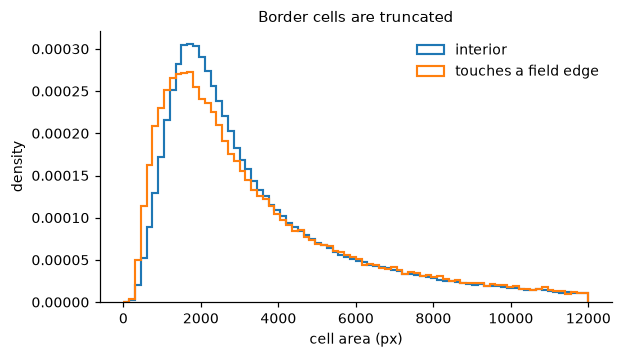

In [3]:
area_column = adata.var.index[
    (adata.var.family == "Morphology") & (adata.var.statistic == "area")
][0]
area = np.asarray(adata[:, area_column].X).ravel()

fig, ax = plt.subplots(figsize=(6, 3.2))
for is_border, label in [(False, "interior"), (True, "touches a field edge")]:
    ax.hist(area[adata.obs.is_border_external.values == is_border], bins=80,
            range=(0, 12000), histtype="step", density=True, label=label, linewidth=1.4)
ax.set(xlabel="cell area (px)", ylabel="density", title="Border cells are truncated")
ax.legend()

In this case one can see a slight shif to the left indicating an average smaller cell area, however more extreme cases do exist. We anyways remove, these cells from the downstream analysis as a precaution.

In [4]:
clean = adata[~adata.obs.is_border_external.values].copy()
print(f"{adata.n_obs:,} cells -> {clean.n_obs:,} "
      f"({1 - clean.n_obs / adata.n_obs:.1%} removed)")

# This line is the memory peak of the whole of Part 3: for a moment `adata` and `clean`
# both exist, roughly 1.9x the slim table. In a tight session, free the original:
#     import gc; del adata; gc.collect()

733,556 cells -> 653,948 (10.9% removed)


:::{note}
We keep the internal-border cells. They sit on a seam between two imaged fields of the
same well, where the image is still complete — the flag marks a stitching boundary, not
a truncated cell. Dropping them too is defensible; dropping them *without saying so* is
not.
:::

## Step 12 · Should any wells be dropped?

Cells are cheap to drop — there are hundreds of thousands. A **well** is one of only
224, and one of only three replicates of its condition at its timepoint. Dropping one
costs a third of the evidence for that comparison, so the bar has to be higher.

Start with the most basic thing a well can fail at: **did anything grow in it?**

In [5]:
counts = (clean.obs.groupby(["well", "timepoint_h", "condition"], observed=True)
          .size().rename("cells").reset_index())
counts["timepoint_h"] = counts["timepoint_h"].astype(int)
counts.groupby("timepoint_h")["cells"].describe()[["count", "mean", "min", "max"]].round(0)

,count,mean,min,max
timepoint_h,,,,
36,56.0,1324.0,1007.0,1604.0
48,56.0,1880.0,1216.0,2370.0
60,56.0,3480.0,1854.0,4901.0
84,56.0,4994.0,476.0,6674.0


**The mean is mostly telling you the timepoint.** The cells are still dividing, so an
84-hour well holds three to four times what a 36-hour well does. A single global
threshold would delete most of the 36-hour plate for being 36 hours old.

:::{note}
The count indicates the number of wells for that timepoint.
The mean tells you the mean number of cells for that timepoint.
:::

So compare each well to **its own timepoint**.

In [6]:
# Here we calculate how far away is each well from the timepoint median
counts["share"] = counts.groupby("timepoint_h")["cells"].transform(lambda s: s / s.median())
counts["share"]

0      0.760861
1      0.998867
2      0.863619
3      0.981488
4      0.758566
         ...   
219    0.795562
220    0.501418
221    0.989038
222    0.879796
223    0.865432
Name: share, Length: 224, dtype: float64

#### We can plot this deviation from the timepoint median

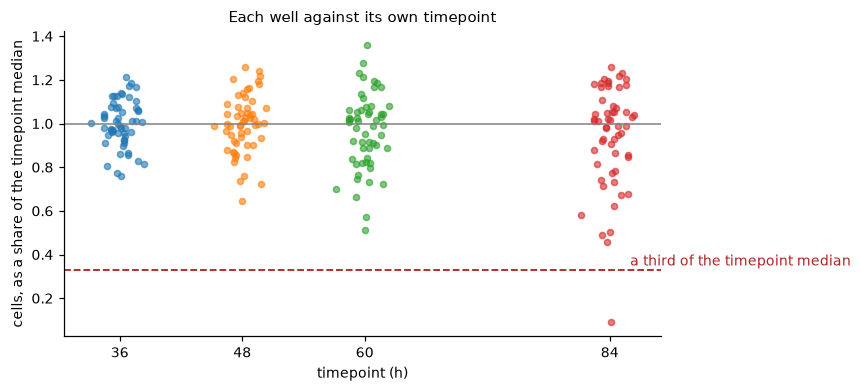

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for timepoint, block in counts.groupby("timepoint_h"):
    ax.scatter(np.full(len(block), timepoint) + np.random.default_rng(0).normal(0, 1.2, len(block)),
               block.share, s=16, alpha=0.6, label=f"{timepoint} h")
ax.axhline(1.0, color="0.5", lw=1)
ax.axhline(0.33, color="firebrick", lw=1.2, ls="--")
ax.annotate("a third of the timepoint median", (86, 0.35), fontsize=9, color="firebrick")
ax.set(xlabel="timepoint (h)", ylabel="cells, as a share of the timepoint median",
       title="Each well against its own timepoint")
ax.set_xticks([36, 48, 60, 84])

#### We can also flag these wells that are outliers

In [8]:
counts.nsmallest(8, "share")[["well", "timepoint_h", "condition", "cells", "share"]].round(3)

,well,timepoint_h,condition,cells,share
15,B23,84,PF-4708671,476,0.090
127,I23,84,Sapanisertib/INK128,2433,0.460
94,G22,84,Sapanisertib/INK128,2598,0.491
220,O20,84,Sapanisertib/INK128,2653,0.501
216,O14,60,Sapanisertib/INK128,1854,0.514
8,B14,60,PBS,2063,0.572
60,E20,84,Cycloheximide,3064,0.579
29,C21,84,MK-2206,3283,0.620


One well sits far below everything else. Look at the bottom of the list again:

**`B23` holds 9% of its timepoint's median.** The next-lowest well holds 45%. That is
not a borderline call — it fails by a factor of five against its nearest neighbour, and
there is no threshold between 10% and 45% that would treat them the same.

### The wells you must *not* drop

Look at what comes next in that list, and at which condition those wells are.

In [9]:
counts.nsmallest(6, "share").merge(
    counts[["well"]], on="well")[["well", "timepoint_h", "condition", "cells", "share"]].round(3)

,well,timepoint_h,condition,cells,share
0,B23,84,PF-4708671,476,0.090
1,I23,84,Sapanisertib/INK128,2433,0.460
2,G22,84,Sapanisertib/INK128,2598,0.491
3,O20,84,Sapanisertib/INK128,2653,0.501
4,O14,60,Sapanisertib/INK128,1854,0.514
5,B14,60,PBS,2063,0.572


`I23`, `G22` and `O20` are all **Sapanisertib/INK128** — an mTOR inhibitor. mTOR
controls cell growth and division, so a well treated with it *should* contain fewer
cells. They are sparse because **the drug worked**.

:::{important}
This is the trap the step exists for. A low cell count is sometimes a failed well and
sometimes the phenotype, and the number alone cannot tell you which. Applying a
"minimum 50% of median" rule here would have silently deleted the strongest biological
effect on the plate.

Before dropping a well for being sparse, ask what was done to it.
:::

### A method that does not work here

The instinct is to flag outliers statistically — z-score each well within its own
condition and timepoint, and drop anything extreme. Try it.

The three-well groups — every condition except DMSO — **hit their ceiling exactly**. The
few values above 1.4142 are all DMSO, which has five wells and so a ceiling of 2.0.

So the z-score is not measuring how unusual a well is. It is measuring **how many wells
are in its group**. The most extreme of any three replicates scores 1.41 whether it is a
genuine failure or the ordinary spread of three healthy wells.

:::{warning}
**Outlier detection needs more replicates than this experiment has.** With three wells
there is no statistical test that distinguishes a bad well from an unlucky one. You are
left with what the design gives you: an absolute criterion, applied consistently, and
stated out loud.
:::

### A second, independent check: staining level

Cell count says whether anything grew. It says nothing about whether the staining
worked. Median DAPI per well is an independent readout — the same stain, on every
nucleus, in every well.

  range 0.42 to 1.26 of the timepoint median


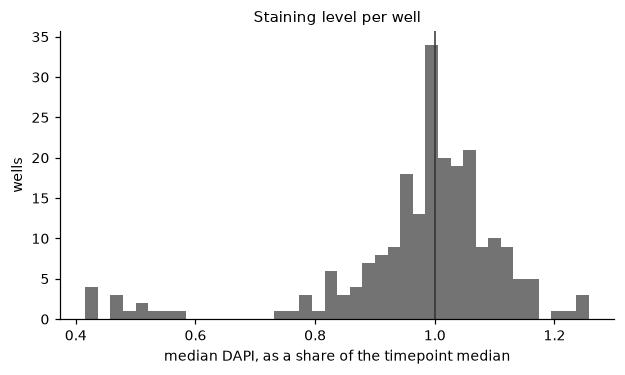

In [10]:
dapi_column = clean.var.index[
    (clean.var.channel == "DAPI") & (clean.var.statistic == "mean_intensity")
    & (clean.var["round"] == 0)
][0]
dapi = pd.DataFrame({
    "well": clean.obs.well.astype(str).values,
    "timepoint_h": clean.obs.timepoint_h.astype(int).values,
    "dapi": np.asarray(clean[:, dapi_column].X).ravel(),
})
per_well = dapi.groupby(["well", "timepoint_h"], observed=True)["dapi"].median().reset_index()
per_well["share"] = per_well.groupby("timepoint_h")["dapi"].transform(lambda s: s / s.median())

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(per_well.share, bins=40, color="0.45")
ax.axvline(1.0, color="0.2", lw=1)
ax.set(xlabel="median DAPI, as a share of the timepoint median", ylabel="wells",
       title="Staining level per well")
print(f"  range {per_well.share.min():.2f} to {per_well.share.max():.2f} of the timepoint median")

A roughly threefold spread, with no separated tail — no well failed to stain. This is a
check that comes back negative, and that is a perfectly good outcome: you now know that
staining variation is not driving anything you find later.

### The decision

In [11]:
worst = counts.nsmallest(2, "share")
DROPPED_WELLS = [worst.iloc[0].well]
DROP_REASON = (f"{worst.iloc[0].share:.0%} of its timepoint median cell count; "
               f"next-lowest well ({worst.iloc[1].well}) is {worst.iloc[1].share:.0%}")

before = clean.n_obs
clean = clean[~clean.obs.well.astype(str).isin(DROPPED_WELLS)].copy()
clean.uns["dropped_wells"] = {w: DROP_REASON for w in DROPPED_WELLS}

print(f"  dropped {len(DROPPED_WELLS)} well(s): {DROPPED_WELLS}")
print(f"  reason : {DROP_REASON}")
print(f"  cells  : {before:,} -> {clean.n_obs:,}")
print(f"  wells  : {clean.obs.well.nunique()} remain")

  dropped 1 well(s): ['B23']
  reason : 9% of its timepoint median cell count; next-lowest well (I23) is 46%
  cells  : 653,948 -> 653,472
  wells  : 223 remain


One well, recorded in `uns` with the number that justified it. Anyone reading this
object later can find out what was removed without reading the notebook.

## Step 13 · Does plate position matter?

The plate is laid out so that position and treatment *can* be told apart. **Each condition
is spread across three or four different rows**, so a row-wise artefact is not the same
shape as a treatment effect: it cuts across conditions instead of following one.

That still leaves the controls as the cleanest readout, because their treatment is fixed.
They are not in every row — DMSO holds rows D, H, I and O, PBS holds B, L and M, seven of
fourteen between them — but within those rows anything that varies from row to row is the
plate rather than the biology.

**Plate column is a different matter: it *is* the timepoint.** Columns 2–5 are all 36 h,
8–11 are 48 h, 14–17 are 60 h, 20–23 are 84 h. A column-wise difference is the experiment
working, and correcting it away would delete the time course
([chapter 03](03_normalisation.ipynb) turns on exactly this point). Row is the axis that
carries no design meaning, which is why row is the one worth checking.

<Axes: title={'center': 'Mean marker intensity per well (log2)'}>

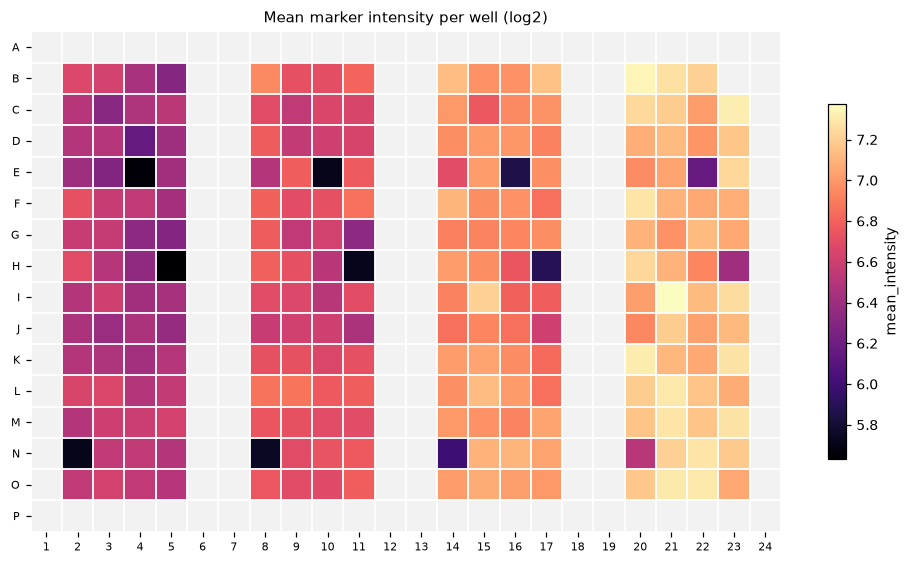

In [12]:
marker_columns = analysis.marker_columns(clean.var)
wells = analysis.by_well(clean, marker_columns, name_by="marker")
names = [clean.var.loc[c, "marker"] for c in marker_columns]


wells["mean_intensity"] = np.log2(wells[names] + 1).mean(axis=1)
wells["row"] = wells.well.str[0]
wells["column"] = wells.well.str[1:].astype(int)
plotting.plate_map(wells, "mean_intensity", cmap="magma",
                   title="Mean marker intensity per well (log2)")

## Step 14 · Save the cleaned table

In [ ]:
clean.write_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"), compression="gzip")
print(f"  {clean.n_obs:,} cells x {clean.n_vars:,} features")
print(f"  {clean.obs.well.nunique()} wells, {clean.obs.condition.nunique()} conditions")
print(f"  dropped wells recorded in uns: {clean.uns['dropped_wells']}")

### What this chapter removed

| | |
|---|---|
| border cells | ~11%, truncated by the edge of a field |
| `B23` | one well, 9% of its timepoint's cell count |
| *nothing else* | low-yield INK128 wells kept — that is the drug working |




---

**Next:** [03 · Normalisation](03_normalisation.ipynb) — making the numbers comparable.